O pré-processamento típico segue essa ordem:

- Olhar os tipos (df.info()) e ver o que devia ser número/data mas veio como object/str

- Olhar valores únicos (df["COLUNA"].unique()) pra achar sujeira: espaços, formatos inconsistentes.

- Limpar (strip, trocar separador, etc.)

- Converter pro tipo certo

- Só então calcular estatísticas, agrupar, plotar

In [4]:
import pandas as pd

df = pd.read_csv("../dados/brutos/ufc_fight_stats.csv")

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41040 entries, 0 to 41039
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EVENT         41040 non-null  str    
 1   BOUT          41040 non-null  str    
 2   ROUND         41040 non-null  str    
 3   FIGHTER       41040 non-null  str    
 4   KD            41040 non-null  int64  
 5   SIG.STR.      41040 non-null  int64  
 6   SIG.STR. %    40870 non-null  float64
 7   TOTAL STR.    41040 non-null  int64  
 8   TD            41040 non-null  int64  
 9   TD %          21906 non-null  float64
 10  SUB.ATT       41040 non-null  int64  
 11  REV.          41040 non-null  int64  
 12  CTRL          41040 non-null  str    
 13  HEAD          41040 non-null  int64  
 14  BODY          41040 non-null  int64  
 15  LEG           41040 non-null  int64  
 16  DISTANCE      41040 non-null  int64  
 17  CLINCH        41040 non-null  int64  
 18  GROUND        41040 non-null  int64  

In [6]:
resultados = pd.read_csv("../dados/processados/ufc_fight_results.csv")
chave = ["EVENT", "BOUT"]

# Garante que as chaves estão no mesmo formato nas duas tabelas
df["EVENT"] = df["EVENT"].str.strip()
df["BOUT"] = df["BOUT"].str.strip()

# Confere se a chave é única na tabela de referência (senão o merge duplica linhas)
print("Chave única em resultados?", not resultados.duplicated(chave).any())

antes = len(df)
df = df.merge(resultados[chave], on=chave, how="inner", validate="many_to_one")
print(f"Linhas: {antes} -> {len(df)}")


Chave única em resultados? True
Linhas: 42012 -> 41040


In [7]:
# Conferência: todas as lutas da referência têm estatísticas?
lutas_stats = df[chave].drop_duplicates()
sem_stats = resultados[chave].merge(lutas_stats, on=chave, how="left", indicator=True)
print(sem_stats["_merge"].value_counts())   # o ideal é tudo em "both"


_merge
both          8625
left_only        0
right_only       0
Name: count, dtype: int64


In [29]:
var = 'ROUND'

df[var].unique()
# df[var].count()

<StringArray>
['Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5']
Length: 5, dtype: str

In [9]:
df[var]

0        23 of 65
1        36 of 75
2        20 of 49
3         8 of 16
4         5 of 19
           ...   
41035      0 of 3
41036     5 of 23
41037     6 of 11
41038      0 of 3
41039      0 of 4
Name: DISTANCE, Length: 41040, dtype: str

Excluir os nulos e tranformar em Int


In [10]:
df = df.dropna(subset=["FIGHTER"])          # linhas sem lutador = linha vazia
df['KD'] = df['KD'].astype(int)


Uma coluna somente com o número de golpes significativos

In [11]:
df["SIG.STR."] = df["SIG.STR."].str.split(" of ").str[0].astype(int)

Trocando um texto de '10%' para 0.10

In [12]:
df["SIG.STR. %"] = pd.to_numeric(df["SIG.STR. %"].str.rstrip("%"), errors="coerce") / 100
df["TD %"]       = pd.to_numeric(df["TD %"].str.rstrip("%"), errors="coerce") / 100



Uma coluna somente com o número de golpes

In [13]:


partes = df["TOTAL STR."].str.split(" of ", expand=True).astype(int)

df["TOTAL STR. %"] = partes[0] / partes[1]   # 0 tentativas -> divisão por zero -> NaN
df["TOTAL STR."]   = partes[0]               # sobrescreve só no fim


Uma coluna somente com o número de Takedowns 

In [14]:
df["TD"] = df["TD"].str.split(" of ").str[0].astype(int)

Mudando tentativas de finalização e reversões para int

In [15]:
df = df.dropna(subset=["SUB.ATT"])        
df['SUB.ATT'] = df['SUB.ATT'].astype(int)

df = df.dropna(subset=["REV."])        
df['REV.'] = df['REV.'].astype(int)

Tempo de controle 

In [16]:
ctrl = df["CTRL"].replace("--", None)
partes = ctrl.str.split(":", expand=True).apply(pd.to_numeric)
df["CTRL_SEG"] = partes[0] * 60 + partes[1]


Total de golpes na cabeça

In [17]:
partes = df["HEAD"].str.split(" of ", expand=True).astype(int)

df["HEAD %"] = partes[0] / partes[1]  
df["HEAD"]   = partes[0] 

Total de golpes no corpo

In [18]:
partes = df["BODY"].str.split(" of ", expand=True).astype(int)

df["BODY %"] = partes[0] / partes[1]  
df["BODY"]   = partes[0] 

Total de golpes na perna

In [19]:
partes = df["LEG"].str.split(" of ", expand=True).astype(int)

df["LEG %"] = partes[0] / partes[1]  
df["LEG"]   = partes[0] 

Corrigindo o formato das colunas [DISTANCE], [CLINCH], [GROUND]

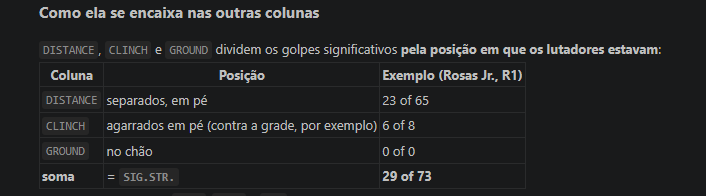

In [22]:
partes = df["DISTANCE"].str.split(" of ", expand=True).astype(int)

df["DISTANCE %"] = partes[0] / partes[1]  
df["DISTANCE"]   = partes[0] 

In [26]:
partes = df["CLINCH"].str.split(" of ", expand=True).astype(int)

df["CLINCH %"] = partes[0] / partes[1]  
df["CLINCH"]   = partes[0] 

In [27]:
partes = df["GROUND"].str.split(" of ", expand=True).astype(int)

df["GROUND %"] = partes[0] / partes[1]  
df["GROUND"]   = partes[0] 

Corrigindo Round

In [30]:
df["ROUND"] = df["ROUND"].str.replace("Round ", "").astype(int)

In [34]:
chaves = ["EVENT", "BOUT", "FIGHTER", "ROUND"]
outras = sorted(c for c in df.columns if c not in chaves)

df = df[chaves + outras]


In [35]:
df.columns.tolist()


['EVENT',
 'BOUT',
 'FIGHTER',
 'ROUND',
 'BODY',
 'BODY %',
 'CLINCH',
 'CLINCH %',
 'CTRL',
 'CTRL_SEG',
 'DISTANCE',
 'DISTANCE %',
 'GROUND',
 'GROUND %',
 'HEAD',
 'HEAD %',
 'KD',
 'LEG',
 'LEG %',
 'REV.',
 'SIG.STR.',
 'SIG.STR. %',
 'SUB.ATT',
 'TD',
 'TD %',
 'TOTAL STR.',
 'TOTAL STR. %']